- copied the API key from football-data.org after registering

In [4]:
# install necessary libraries
!pip install requests pandas matplotlib seaborn


In [ ]:
#setting up the python script to fetch the epl matches
import requests
import pandas as pd

#applying my API key
api_key = "0311aa1c78544ef28b920e0d26aa9ee3"
headers = {"X-Auth-Token": api_key}

#premier league competition code = PL
url = "https://api.football-data.org/v4/competitions/PL/matches?season=2024"
# Constructs the API endpoint URL to get all match results for the Premier League (competition code: 'PL')
# for the 2024–2025 season. This includes match status, scores, teams, and dates.

response = requests.get(url, headers=headers) # this function calls a web API and asks for data
# headers=headers includes the API key in the request so the server knows you are authorized to access
# the data

data = response.json()# Convert the API response from JSON format into a Python dictionary.
# This allows us to access and work with the data using Python data structures like dictionaries and lists.

matches = data["matches"]# Extract the list of match data from the 'data' dictionary.
# The API response has a key called "matches" that holds all the individual match records,
# so we assign that list to the variable 'matches' for easier access.

#### reasoning for the script

- APIs often return data in JSON format (JavaScript Object Notation), which looks like a structured text file.
- response.json() converts that JSON response into a Python dictionary, so you can easily extract data like match scores, team names, and dates using regular Python syntax.
- After calling response.json(), data becomes a dictionary.
- One of the keys in that dictionary is "matches", which stores a list of dictionaries, with each dictionary representing a match (including teams, scores, dates, etc.).
- Storing this list in matches makes it easier to loop through the matches or convert them into a DataFrame.

#### API url explanation
- https://api.football-data.org/v4/competitions/PL/matches?season=2024
#### breakdown
- https://api.football-data.org/v4/ - this serves as the base API endpoint
- competitions/ - this section deals with leagues or tournaments
- PL - the code for the premier league
- /matches - fetches the match level data 
- ?seasons=2024 - specifies that we are asking for the 2024-2025 season
- found when you visit https://www.football-data.org/documentation/quickstart and scroll to competitions

In [8]:
# 1.building a dataframe and calculating win probabilities
df = pd.DataFrame(matches)

# 2.filter only finished matches
df = df[df["status"] == "FINISHED"]

# 3.count wins
teams = {} # Creates an empty dictionary to store each team's total wins and games played
for match in df.itertuples():# Loop through each row (match) in the DataFrame using itertuples() for faster access
    home = match.homeTeam["name"]# Extract the home team name from the match data
    away = match.awayTeam["name"]# Extract the away team name from the match data
    score = match.score["winner"] # Get the result of the match: "home_team", "away_team", or "draw"
# this part of the script prepares to count wins and total matches per team.
# team names and match outcome are extracted from each row of the DataFrame.

    teams.setdefault(home, {"Wins": 0, "Games": 0})
    teams.setdefault(away, {"Wins": 0, "Games": 0})
# Ensure that both the home and away teams have an entry in the 'teams' dictionary.
# If a team doesn't exist yet, set its initial values: 0 wins and 0 games played.
# "setdefault" prevents overwriting existing data and avoids key errors.
#This step guarantees that every team in the dataset has a place in the teams dictionary.
#It’s especially useful the first time we encounter a team in the loop.
#From here, we can safely increment their win or game count later without causing errors.

    teams[home]["Games"] += 1
    teams[away]["Games"] += 1
#increments the number of games played for both home and away teams by 1
# this keeps track of the number of matches each team has participated in

    if score == "HOME_TEAM":
        teams[home]["Wins"] += 1
    elif score == "AWAY_TEAM":
        teams[away]["Wins"] += 1
# Checks the match outcome to update the winning team's win count:
# If the home team won, increment its win count by 1.
# If the away team won, increment its win count by 1.
# Draws are ignored in this win probability calculation.

# 4.convert to dataframe
team_stats = pd.DataFrame([{"Team": k, "Wins": v["Wins"], "Games": v["Games"], "Win Probability (%)": round((v["Wins"]/v["Games"])*100, 2)}
                           for k, v in teams.items()
                           ])
# Creates a new DataFrame called 'team_stats' from the 'teams' dictionary.
# For each team (key "k"), extract its number of wins and games (value "v"),
# then calculate the win probability as (Wins / Games) * 100, rounded to 2 decimal places.
# The result is a structured table with columns: Team, Wins, Games, and Win Probability (%).

# 5.sort by win probability
team_stats = team_stats.sort_values(by = "Win Probability (%)", ascending = False)
print(team_stats)

    


                          Team  Wins  Games  Win Probability (%)
3                 Liverpool FC    25     38                65.79
17          Manchester City FC    21     38                55.26
4                   Arsenal FC    20     38                52.63
16                  Chelsea FC    20     38                52.63
8          Newcastle United FC    20     38                52.63
10        Nottingham Forest FC    19     38                50.00
13              Aston Villa FC    19     38                50.00
14                Brentford FC    16     38                42.11
7    Brighton & Hove Albion FC    16     38                42.11
11             AFC Bournemouth    15     38                39.47
1                    Fulham FC    15     38                39.47
15           Crystal Palace FC    13     38                34.21
5   Wolverhampton Wanderers FC    12     38                31.58
0         Manchester United FC    11     38                28.95
19        Tottenham Hotsp

#### Breakdown of the script
- First a DataFrame is created and the list of matches(fetched from the API) is converted into a Pandas DataFrame for easier data manipulation
- Finished Matches are then filtered and I only analyzed matches that have already been played. Here, I excluded scheduled or in-progress games to ensure accurate win statistics
- I initialized the team win data by creating an empty dictionary to keep track of; number of games played per team, number of wins per team
- I Looped through each match in the dataframe extracting the home and away team names as well as the match results
- I initialized each team in a dictionary. If a team isnt yet in the teams directory, its added with 0 wins and 0 games.
- I Updated games played by incrementing the number of games played for both teams involved in the match.
- I updated wins based on match results. the win count was incremented for the team that won the match and draws were not counted as wins
- I converted the dictionary into a structured DataFrame including; Team name, Number of wins, Number of games, Calculated win probability as a percentage
- I finally sorted  the teams by Win Probability from highest to lowest to easily identify the top performing clubs

C:\Users\USER\AppData\Local\Temp\ipykernel_1968\2131689326.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_stats, x="Win Probability (%)", y="Team", palette="viridis")


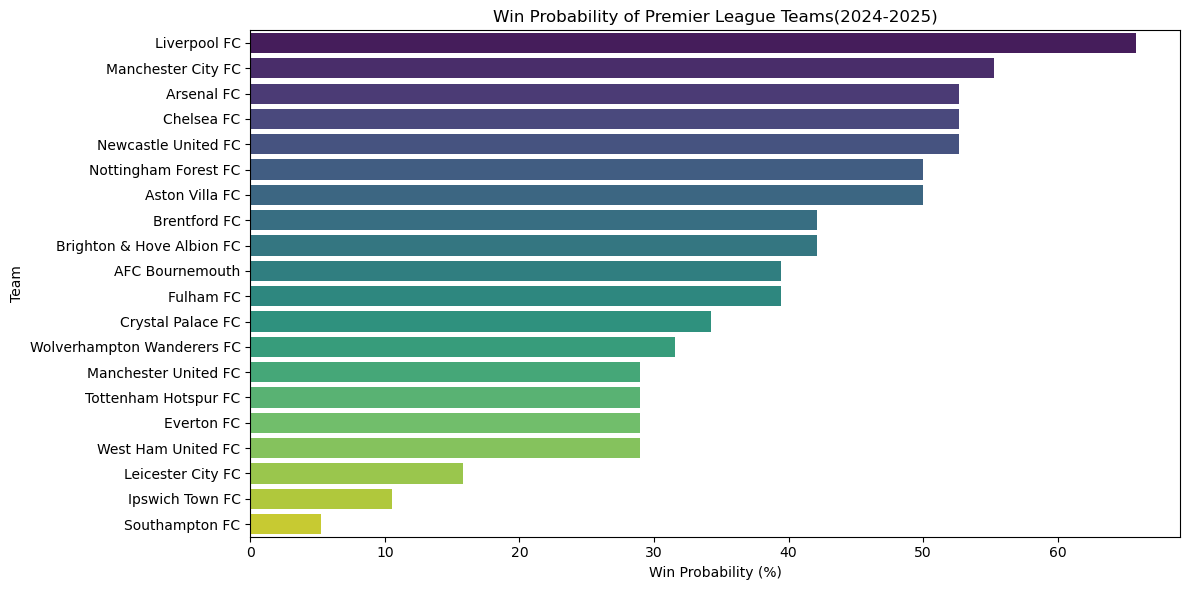

In [10]:
# visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=team_stats, x="Win Probability (%)", y="Team", palette="viridis")
plt.title("Win Probability of Premier League Teams(2024-2025)")
plt.xlabel("Win Probability (%)")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

#### Valuable insights from the barchart
- a) Top performing teams
- Liverpool FC stands out with the highest win probability, just above 60%, showing strong form this season
- Manchester City FC and Arsenal FC follow closely indicating their consistency in winning most of their matches
- Chelsea FC and Newcastle FC also rank highly showing a competitive top 5 battle
- These 5 teams are likely title contenders or top four finishers based on their win rate
- b) mid table performers
- Teams like Brenford FC, Aston Villa FC, Fulham FC and Brighton & Hove Albion FC sit in the mid-range(35%-45% win probability) 
- This range suggests these clubs are competitive possibly fighting for Europa league or mid table positions
- c) Underperforming teams
- Southampton FC, Ipswich Town FC and Leicester City FC have the lowest win probabilities(below 20%)
- These teams could be facing a risk of relegation if this trend continues
- West Ham FC, Everton FC and Tottenham FC appear lower than expected, showing poor form or inconsistency